In [859]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load the dataset
df = pd.read_excel('School_data.xlsx')
df1 = pd.read_excel("FLHS_Datasheet.xlsx")
df2 = pd.read_excel("MSS_Datasheet.xlsx")
df2.columns,df1.columns = df.columns, df.columns

data = pd.concat((df,df1, df2), axis = 0)
data['Class'] = data['Class'].str.replace(' ', '')
data

,Student's Name,School's Name,Class,Gender,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global
0,Gift Etim Nna,"Community Secondary Commercial School, Ikot In...",JS1,F,12,0,1,1,0,0,1,1,0
1,Saviour Ubong Sunday,"Community Secondary Commercial School, Ikot In...",JS1,M,15,1,0,0,1,0,1,1,0
2,Mary Francis Akpabio,"Community Secondary Commercial School, Ikot In...",JS1,F,13,0,1,0,1,0,1,0,1
3,Anthony Luke Offiong,"Community Secondary Commercial School, Ikot In...",JS1,M,12,1,0,1,0,0,1,1,0
4,Gospel Cletus Ntuen,"Community Secondary Commercial School, Ikot In...",JS1,M,13,0,1,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,GOD'STIME OKON AKPAN,"METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN",SS3,M,20,0,1,0,1,0,1,1,0
222,JOHN SAMUEL FRIDAY,"METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN",SS3,M,16,1,0,1,0,1,0,1,0
223,EMMANUEL DOMINIC OKON,"METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN",SS3,M,17,0,1,0,1,1,0,0,1
224,DEBORAH JOSHUA WILLIE,"METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN",SS3,F,17,0,1,0,1,0,1,1,0


In [860]:
data["School's Name"].replace("METHODIST SECONDARY SCHOOL IBIAKU ISSIET, URUAN", "METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN", inplace = True)

In [861]:
data[data["School's Name"] == "METHODIST SECONDARY SCHOOL IBIAKU ISSIET, URUAN"]

,Student's Name,School's Name,Class,Gender,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global


# Data Analysis

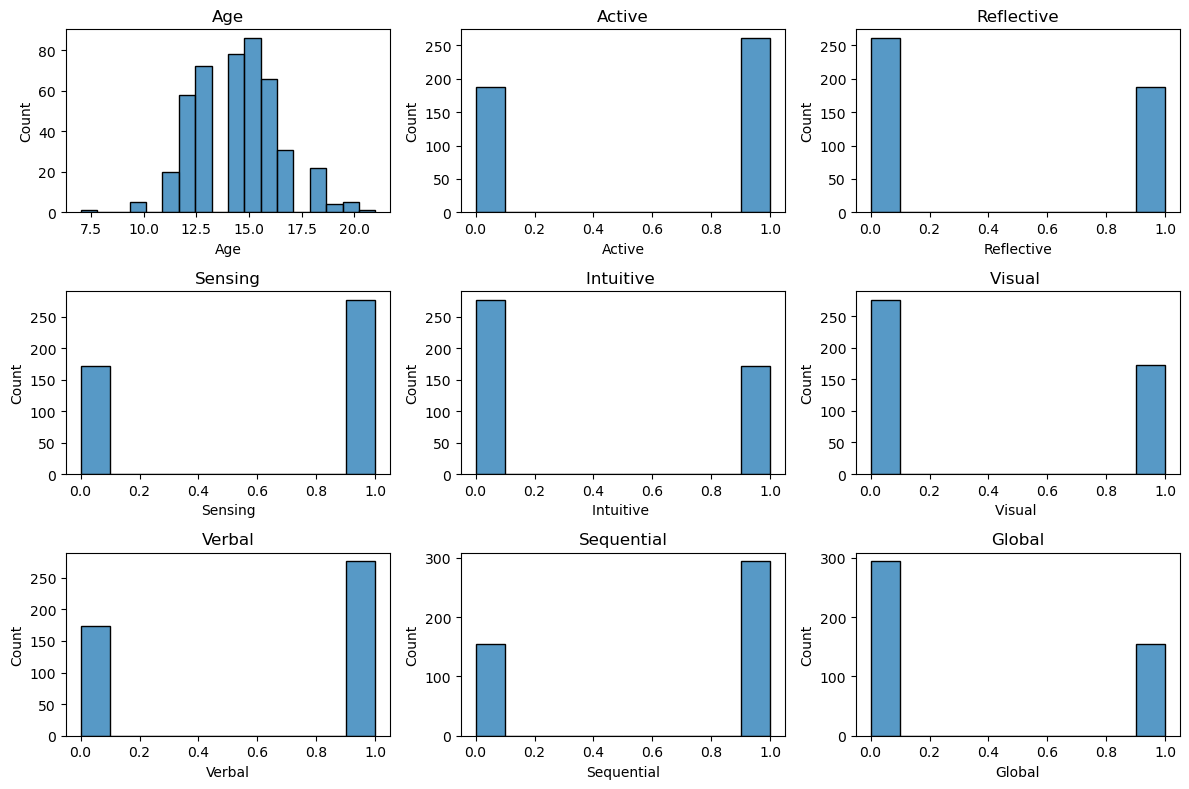

In [862]:
# Select relevant features for clustering
features = ['Age', 'Active', 'Reflective', 'Sensing', 'Intuitive ', 'Visual ', 'Verbal', 'Sequential', 'Global']

# Visualize the distributions of features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [863]:
# sb.pairplot(data_reset.iloc[:, 1:],hue='Gender');

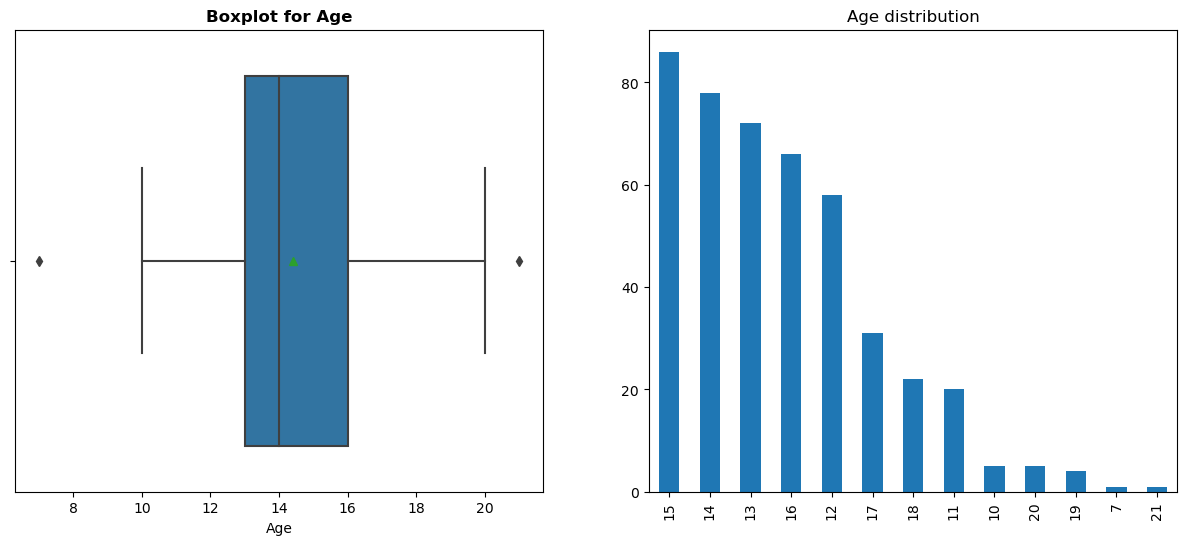

In [864]:
bi = [10,15,20,25]
plt.subplots(1,2,figsize=(15,6))
plt.subplot(121)
sb.boxplot(x='Age',data=data,showmeans=True)
plt.title('Boxplot for Age',fontweight='bold',size=12)
plt.subplot(122)
data["Age"].value_counts().plot(kind = 'bar',
                               title = 'Age distribution');

In [865]:
data.columns

Index(['Student's Name', 'School's Name', 'Class', 'Gender', 'Age', 'Active',
       'Reflective', 'Sensing', 'Intuitive ', 'Visual ', 'Verbal',
       'Sequential', 'Global'],
      dtype='object')

In [866]:
# Convert categorical variables to numerical representations (if needed)
data_encoded = pd.get_dummies(data, columns=['Gender', "School's Name", 'Class'])
data_encoded.drop(['Class_JS2','Class_JS3','Class_SS1','Class_SS2','Class_SS3','Class_SSI',
                  "School's Name_METHODIST SECONDARY SCHOOL, IBIAKU ISSIET, URUAN",'Gender_F',
                  "School's Name_Full Life International Schools (Academy), Airport Road, Uyo"], axis = 1, inplace = True)

In [867]:
data_encoded.columns = ["Student's Name", 'Age', 'Active', 'Reflective', 'Sensing',
       'Intuitive ', 'Visual ', 'Verbal', 'Sequential', 'Global',
       'Gender',
       'School_Name',
       'Class']
data_encoded

,Student's Name,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global,Gender,School_Name,Class
0,Gift Etim Nna,12,0,1,1,0,0,1,1,0,0,1,1
1,Saviour Ubong Sunday,15,1,0,0,1,0,1,1,0,1,1,1
2,Mary Francis Akpabio,13,0,1,0,1,0,1,0,1,0,1,1
3,Anthony Luke Offiong,12,1,0,1,0,0,1,1,0,1,1,1
4,Gospel Cletus Ntuen,13,0,1,0,1,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,GOD'STIME OKON AKPAN,20,0,1,0,1,0,1,1,0,1,0,0
222,JOHN SAMUEL FRIDAY,16,1,0,1,0,1,0,1,0,1,0,0
223,EMMANUEL DOMINIC OKON,17,0,1,0,1,1,0,0,1,1,0,0
224,DEBORAH JOSHUA WILLIE,17,0,1,0,1,0,1,1,0,0,0,0


In [868]:
data_reset = data_encoded.reset_index()  # Reset the index

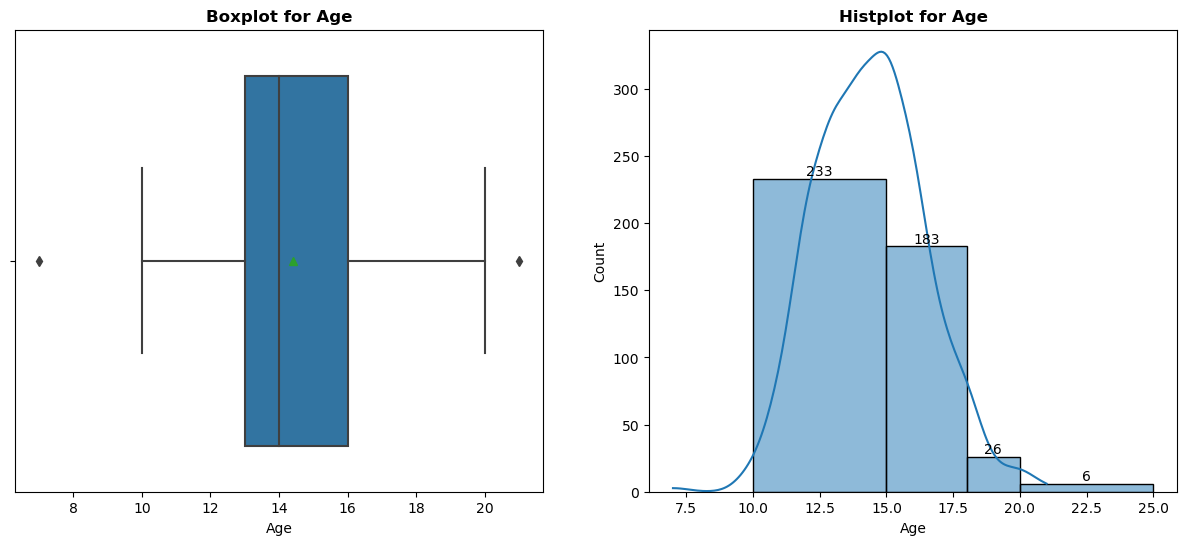

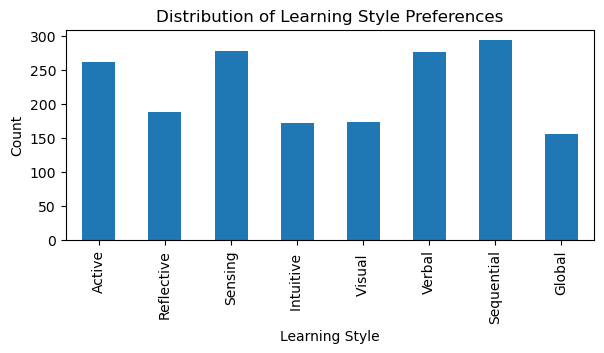

In [897]:
bi = [10,15,20,25]
plt.subplots(1,2,figsize=(15,6))
plt.subplot(121)
sb.boxplot(x='Age',data=data_reset,showmeans=True)
plt.title('Boxplot for Age',fontweight='bold',size=12)
plt.subplot(122)
ax = sb.histplot(data=data_reset,x='Age',bins=b1,kde=True)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Histplot for Age',fontweight='bold',size=12)
plt.show()
plt.subplot(222)
# Bar charts of learning style preferences
style_counts = data_reset[features].sum()
style_counts.plot(kind='bar',figsize=(15,6))
plt.xlabel('Learning Style')
plt.ylabel('Count')
plt.title('Distribution of Learning Style Preferences')
plt.show()


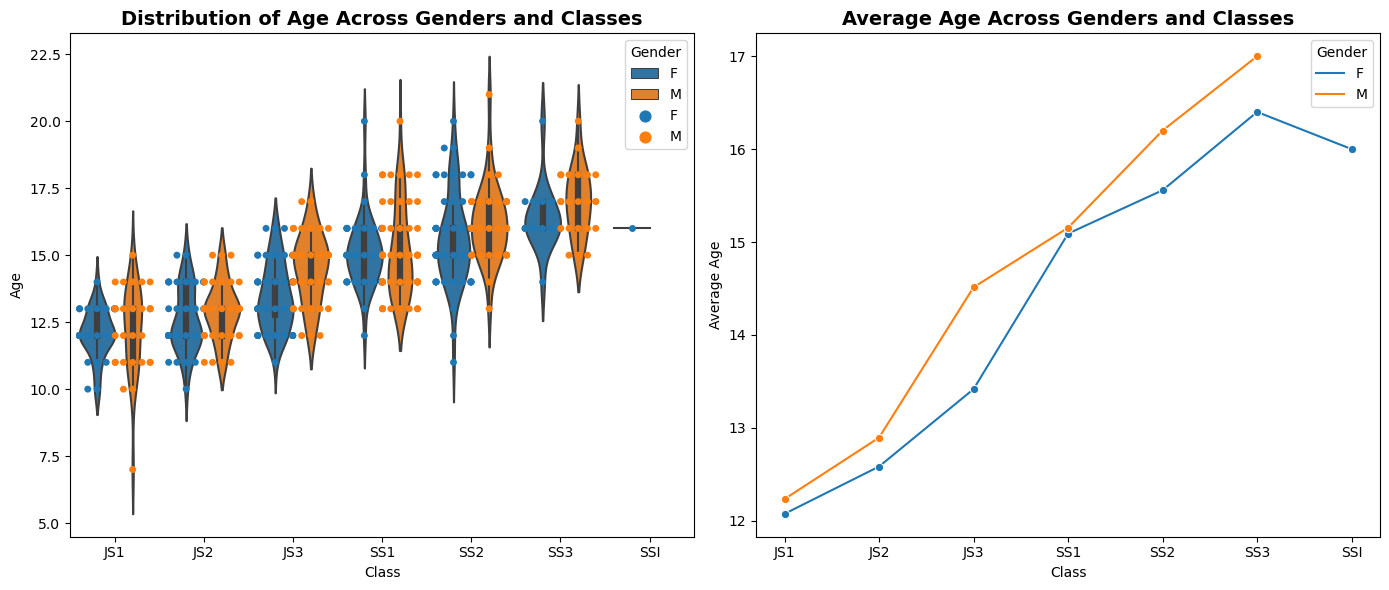

In [870]:
def plot_age_distribution(data):
    # Set up the figure and axes
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot violinplot and swarmplot
    sns.violinplot(x='Class', y='Age', hue='Gender', data=data, ax=axes[0])
    sns.swarmplot(x='Class', y='Age', hue='Gender', data=data, dodge=True, size=5, ax=axes[0])

    # Set labels and title for violin/swarm plot
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Age')
    axes[0].set_title('Distribution of Age Across Genders and Classes',fontweight='bold',size=14)
    axes[0].legend(title='Gender')

    # Aggregate the data to calculate average age for each gender and class combination
    age_gender_class_avg = data.groupby(['Class', 'Gender'])['Age'].mean().reset_index()

    # Plot lineplot
    sns.lineplot(x='Class', y='Age', hue='Gender', data=age_gender_class_avg, marker='o', ax=axes[1])

    # Set labels and title for line plot
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Average Age')
    axes[1].set_title('Average Age Across Genders and Classes',fontweight='bold',size=14)
    axes[1].legend(title='Gender')

    # Adjust subplot spacing
    plt.tight_layout()

    # Show the plot
    plt.show()
plot_age_distribution(data)

In [871]:
data_reset

,index,Student's Name,Age,Active,Reflective,Sensing,Intuitive,Visual,Verbal,Sequential,Global,Gender,School_Name,Class
0,0,Gift Etim Nna,12,0,1,1,0,0,1,1,0,0,1,1
1,1,Saviour Ubong Sunday,15,1,0,0,1,0,1,1,0,1,1,1
2,2,Mary Francis Akpabio,13,0,1,0,1,0,1,0,1,0,1,1
3,3,Anthony Luke Offiong,12,1,0,1,0,0,1,1,0,1,1,1
4,4,Gospel Cletus Ntuen,13,0,1,0,1,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,221,GOD'STIME OKON AKPAN,20,0,1,0,1,0,1,1,0,1,0,0
445,222,JOHN SAMUEL FRIDAY,16,1,0,1,0,1,0,1,0,1,0,0
446,223,EMMANUEL DOMINIC OKON,17,0,1,0,1,1,0,0,1,1,0,0
447,224,DEBORAH JOSHUA WILLIE,17,0,1,0,1,0,1,1,0,0,0,0


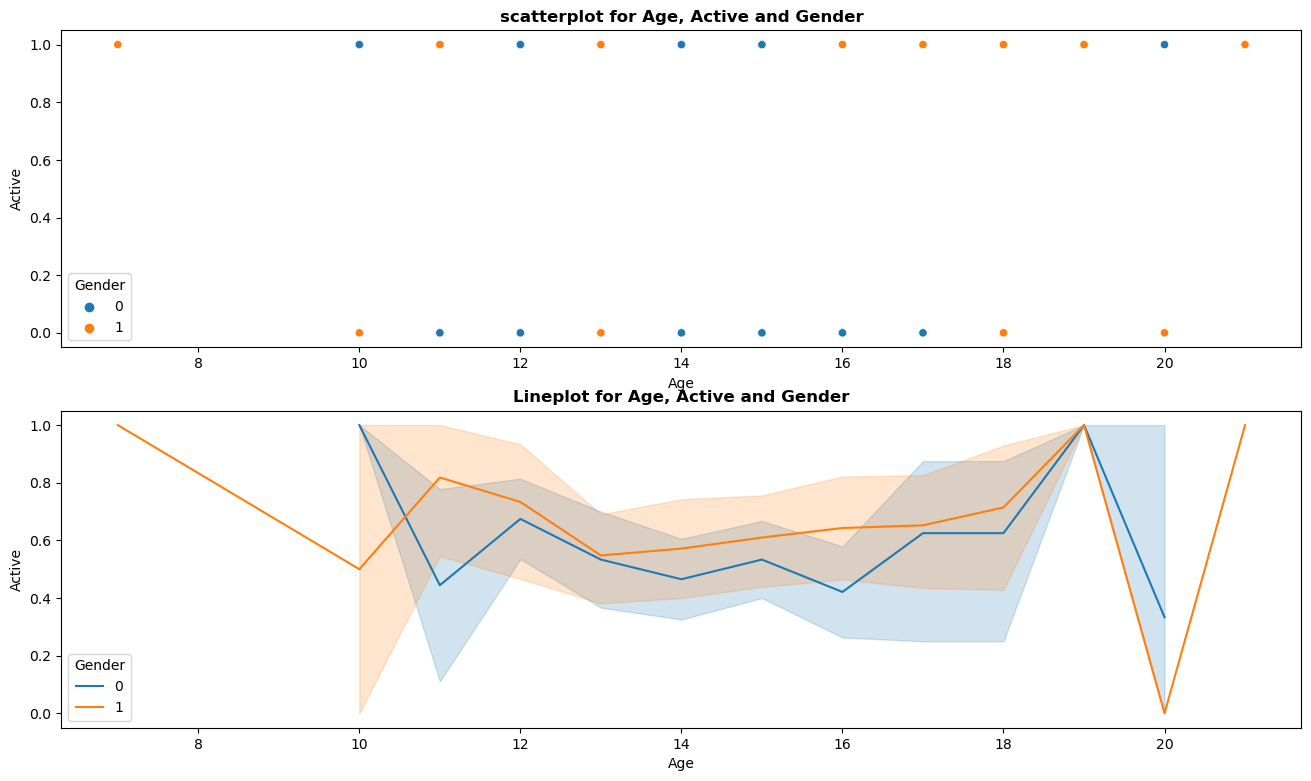

In [872]:
plt.subplots(2,1,figsize=(16,14))
plt.subplot(311)
sb.scatterplot(data=data_reset,x='Age',y='Active',hue='Gender')
plt.title('scatterplot for Age, Active and Gender',fontweight='bold',size=12)
print()
plt.subplot(312)
sb.lineplot(data=data_reset, x='Age', y='Active', hue='Gender')
plt.title('Lineplot for Age, Active and Gender', fontweight='bold', size=12)
plt.show()


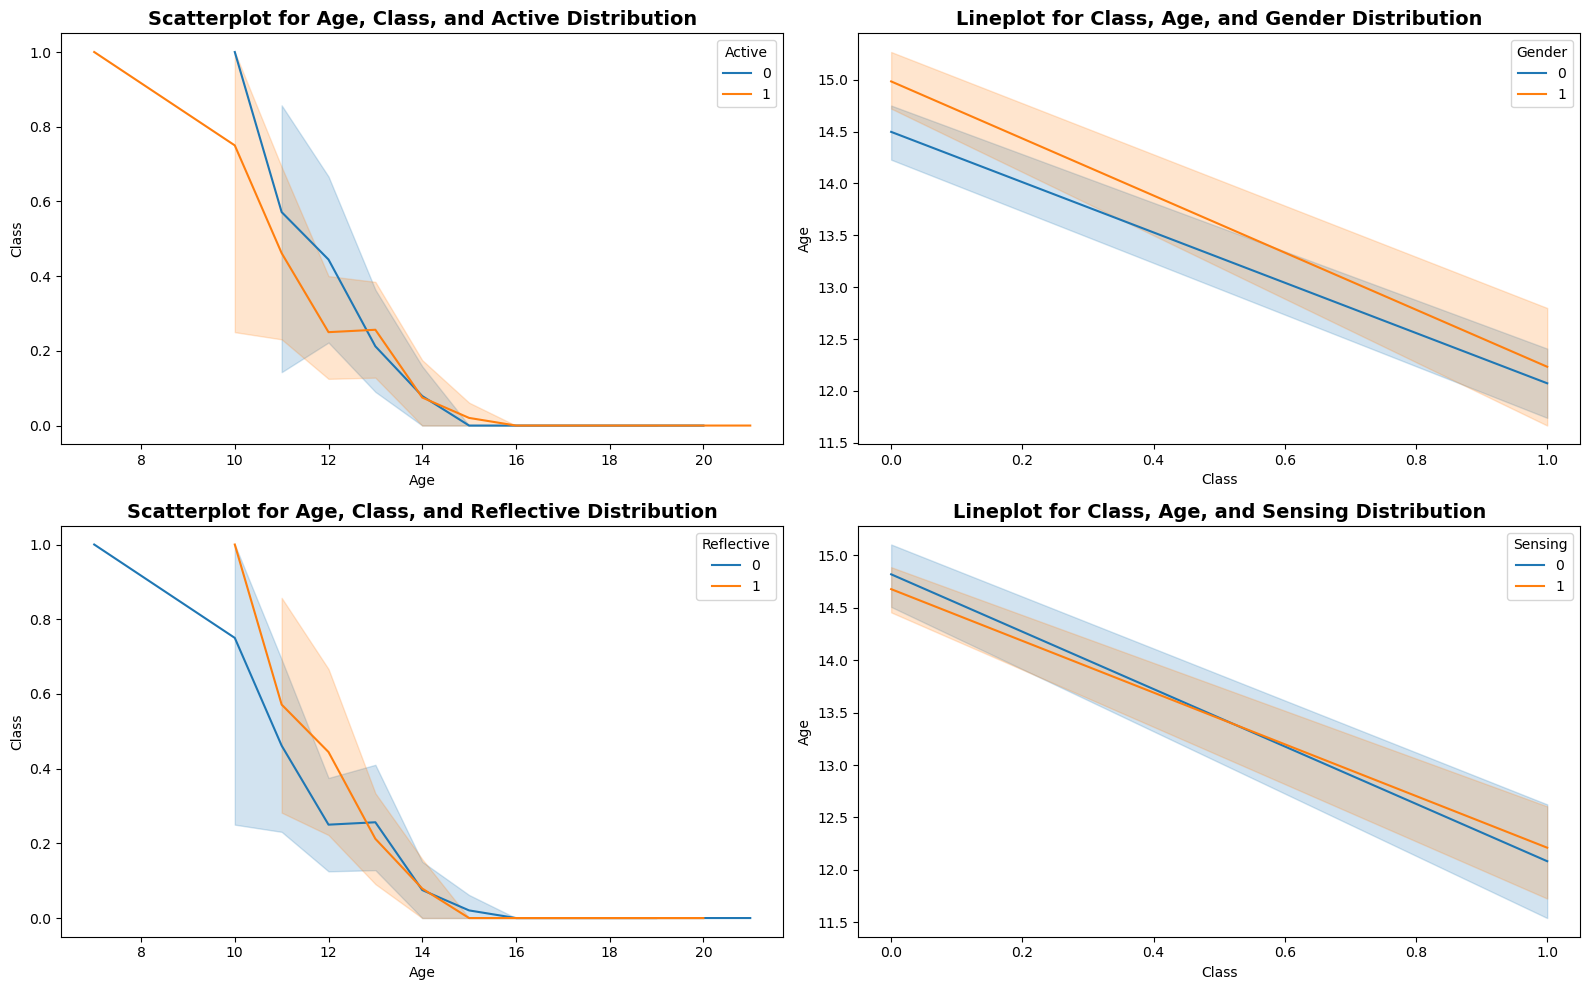

In [873]:
plt.figure(figsize=(16, 10))

# First Line Plot
plt.subplot(221)
ax1 = sb.lineplot(data=data_reset, x='Age', y='Class', hue='Active')
ax1.set_title('Scatterplot for Age, Class, and Active Distribution', fontweight='bold', size=14)
ax1.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Second Line Plot
plt.subplot(222)
ax2 = sb.lineplot(data=data_reset, x='Class', y='Age', hue='Gender')
ax2.set_title('Lineplot for Class, Age, and Gender Distribution', fontweight='bold', size=14)
ax2.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Third Line Plot
plt.subplot(223)
ax3 = sb.lineplot(data=data_reset, x='Age', y='Class', hue='Reflective')
ax3.set_title('Scatterplot for Age, Class, and Reflective Distribution', fontweight='bold', size=14)
ax3.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Fourth Line Plot
plt.subplot(224)
ax4 = sb.lineplot(data=data_reset, x='Class', y='Age', hue='Sensing')
ax4.set_title('Lineplot for Class, Age, and Sensing Distribution', fontweight='bold', size=14)
ax4.title.set_position([0.5, 1.05])  # Adjust the position of the title

plt.tight_layout()
plt.show()

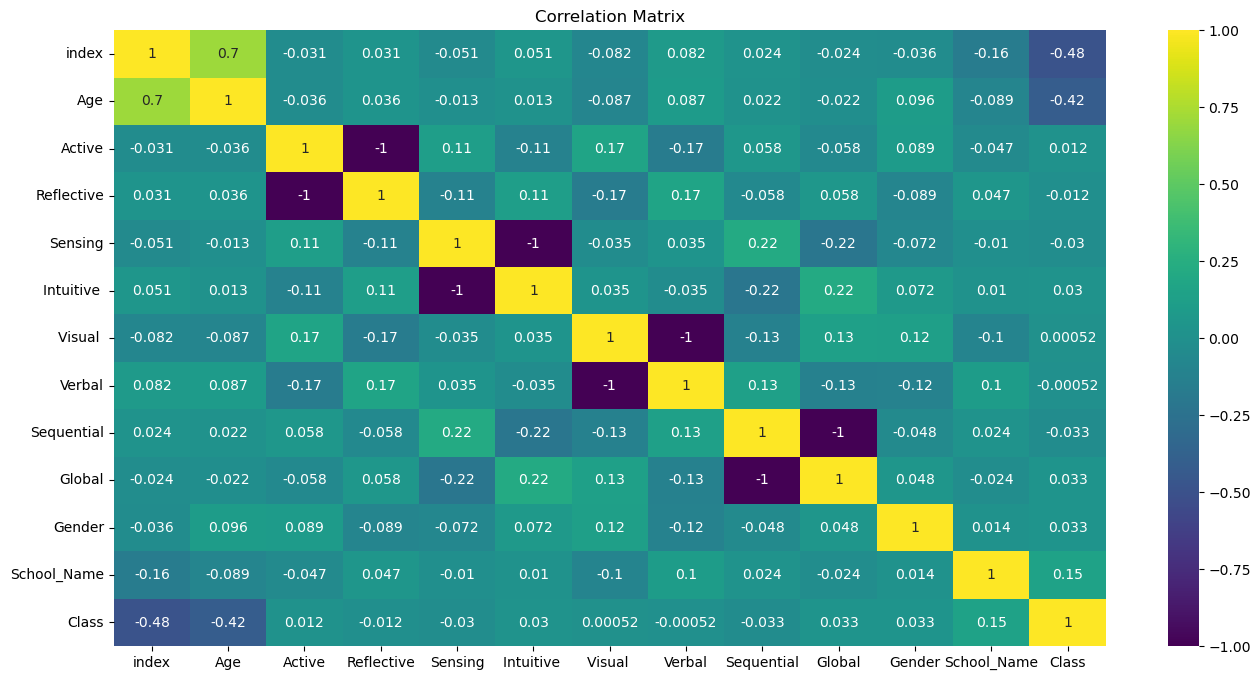

In [874]:
# Calculate the correlation matrix
correlation_matrix = data_reset.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()


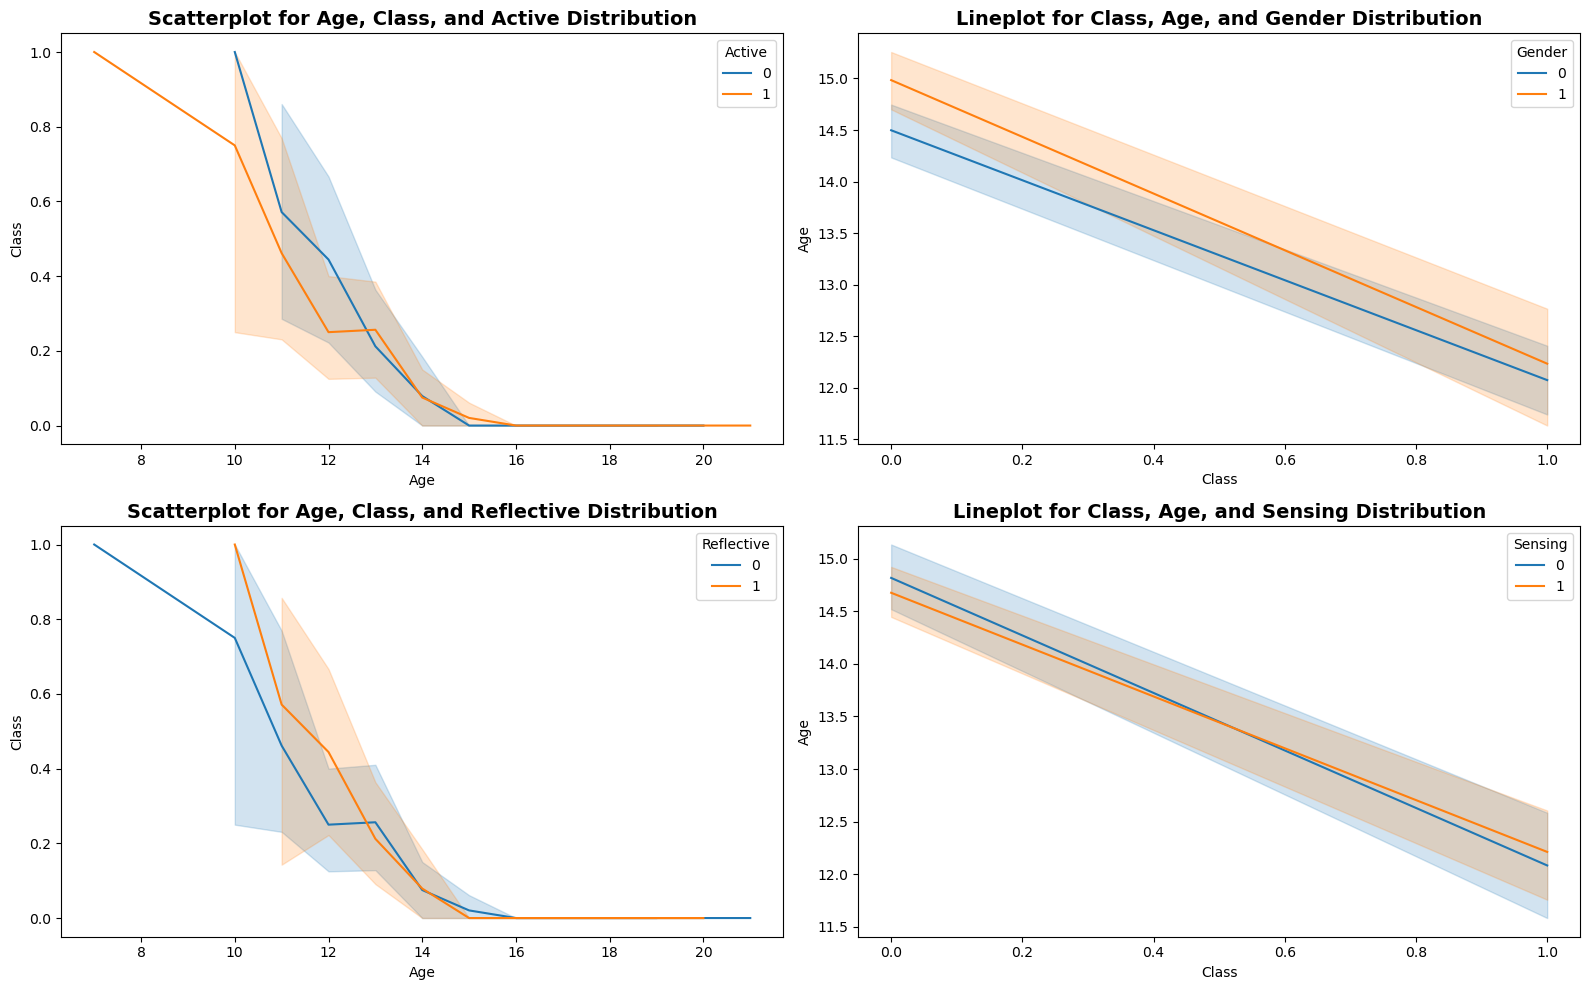

In [875]:
plt.figure(figsize=(16, 10))

# First Line Plot
plt.subplot(221)
ax1 = sb.lineplot(data=data_reset, x='Age', y='Class', hue='Active')
ax1.set_title('Scatterplot for Age, Class, and Active Distribution', fontweight='bold', size=14)
ax1.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Second Line Plot
plt.subplot(222)
ax2 = sb.lineplot(data=data_reset, x='Class', y='Age', hue='Gender')
ax2.set_title('Lineplot for Class, Age, and Gender Distribution', fontweight='bold', size=14)
ax2.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Third Line Plot
plt.subplot(223)
ax3 = sb.lineplot(data=data_reset, x='Age', y='Class', hue='Reflective')
ax3.set_title('Scatterplot for Age, Class, and Reflective Distribution', fontweight='bold', size=14)
ax3.title.set_position([0.5, 1.05])  # Adjust the position of the title

# Fourth Line Plot
plt.subplot(224)
ax4 = sb.lineplot(data=data_reset, x='Class', y='Age', hue='Sensing')
ax4.set_title('Lineplot for Class, Age, and Sensing Distribution', fontweight='bold', size=14)
ax4.title.set_position([0.5, 1.05])  # Adjust the position of the title

plt.tight_layout()
plt.show()


# Data Preprocessing And Modeling

In [876]:
# data = data.drop(['Student\'s Name', 'School\'s Name', 'Class'], axis=1)

# Step 3: Feature Selection/Engineering
features = ['Active', 'Reflective', 'Sensing', 'Intuitive ', 'Visual ', 'Verbal', 'Sequential', 'Global']
X = data_reset.iloc[:, 3:]

# Step 4: Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-means

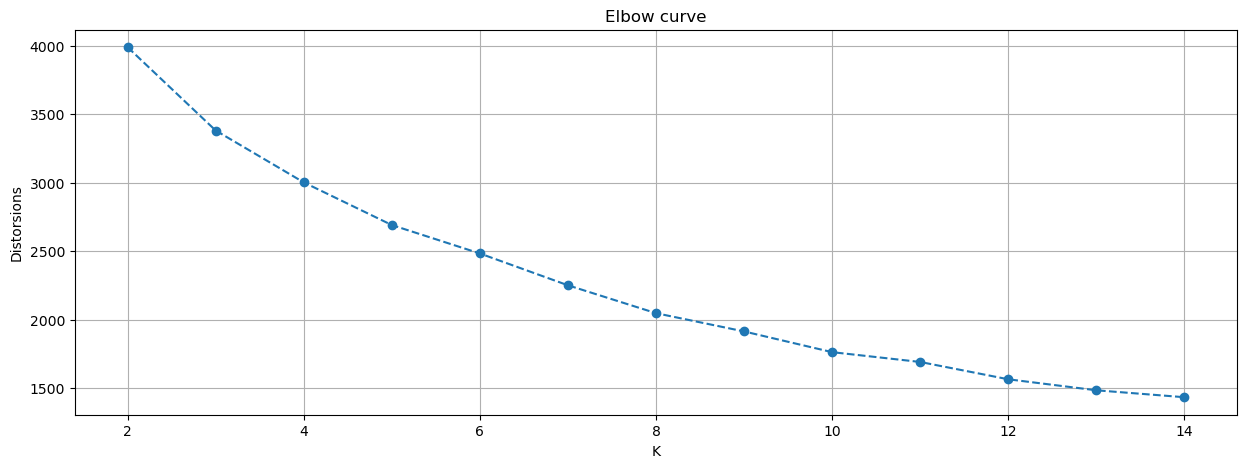

In [877]:
#finding optimum k values
distorsions = []
for k in range(2, 15):
     kmeans = KMeans(n_clusters=k,init='k-means++',max_iter=300,n_init=10)
     kmeans.fit(X_scaled)
     distorsions.append(kmeans.inertia_)
fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, 15), distorsions,'o--')
plt.grid(True)
plt.xlabel('K')
plt.ylabel('Distorsions')
plt.title('Elbow curve');

In [878]:
clusters_range = np.arange(2,15)
for cluster in clusters_range:
    kmeans = KMeans(n_clusters=cluster,init='k-means++',max_iter=300,n_init=10)
    kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_, metric='euclidean')
    print(f'for cluster: {cluster} --> Silhouetter Score: %.3f' % score)

for cluster: 2 --> Silhouetter Score: 0.220
for cluster: 3 --> Silhouetter Score: 0.212
for cluster: 4 --> Silhouetter Score: 0.233
for cluster: 5 --> Silhouetter Score: 0.256
for cluster: 6 --> Silhouetter Score: 0.273
for cluster: 7 --> Silhouetter Score: 0.278
for cluster: 8 --> Silhouetter Score: 0.309
for cluster: 9 --> Silhouetter Score: 0.331
for cluster: 10 --> Silhouetter Score: 0.341
for cluster: 11 --> Silhouetter Score: 0.353
for cluster: 12 --> Silhouetter Score: 0.365
for cluster: 13 --> Silhouetter Score: 0.372
for cluster: 14 --> Silhouetter Score: 0.376


In [879]:
#model building
model = KMeans(n_clusters=5)
model.fit(X_scaled)

KMeans(n_clusters=5)

In [880]:
labels = model.fit_predict(X_scaled)
labels

array([0, 2, 1, 4, 1, 1, 3, 3, 0, 4, 3, 4, 4, 4, 3, 2, 4, 0, 1, 2, 2, 4,
       2, 4, 4, 0, 0, 1, 2, 0, 3, 0, 2, 3, 1, 3, 4, 0, 0, 0, 0, 0, 0, 1,
       0, 2, 4, 3, 2, 0, 4, 4, 1, 0, 2, 0, 4, 3, 1, 2, 2, 4, 3, 4, 3, 0,
       0, 4, 2, 0, 1, 3, 1, 0, 4, 1, 2, 0, 2, 2, 3, 1, 3, 0, 0, 0, 2, 4,
       4, 2, 3, 3, 2, 1, 2, 3, 3, 1, 2, 0, 0, 2, 4, 3, 1, 4, 2, 2, 2, 0,
       2, 2, 4, 2, 0, 1, 4, 4, 1, 3, 3, 2, 3, 4, 2, 2, 2, 0, 1, 0, 1, 3,
       0, 3, 3, 4, 1, 2, 1, 1, 4, 4, 0, 1, 2, 1, 3, 1, 2, 3, 1, 3, 0, 1,
       3, 1, 1, 1, 2, 3, 3, 1, 2, 1, 3, 3, 4, 3, 3, 2, 1, 3, 3, 3, 1, 3,
       1, 3, 4, 1, 4, 2, 1, 3, 1, 1, 1, 3, 2, 2, 2, 1, 1, 4, 3, 3, 3, 1,
       2, 4, 1, 1, 3, 4, 2, 1, 2, 3, 2, 2, 3, 3, 1, 3, 3, 0, 1, 1, 1, 1,
       3, 2, 2, 2, 0, 2, 1, 3, 4, 0, 0, 3, 3, 1, 3, 1, 1, 1, 3, 2, 1, 2,
       4, 4, 0, 4, 3, 3, 4, 4, 3, 3, 4, 2, 0, 3, 1, 0, 3, 0, 1, 2, 2, 3,
       4, 4, 0, 4, 4, 3, 2, 4, 2, 2, 4, 0, 1, 2, 4, 4, 3, 3, 0, 0, 4, 1,
       1, 4, 4, 0, 2, 1, 1, 3, 4, 4, 4, 4, 0, 4, 3,

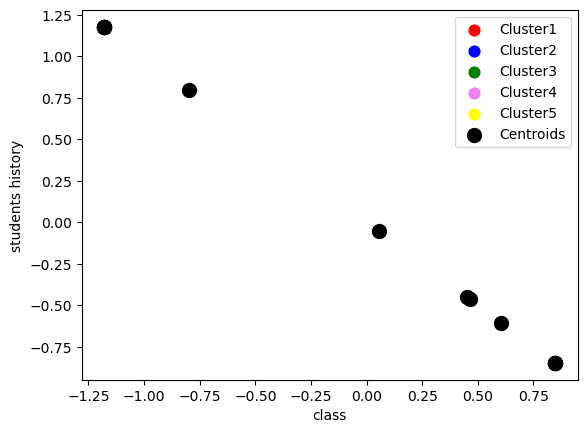

In [881]:
plt.scatter(X_scaled[labels == 0, 0], X_scaled[labels == 0, 1], s = 60, c = 'red', label = 'Cluster1')
plt.scatter(X_scaled[labels == 1, 0], X_scaled[labels == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
plt.scatter(X_scaled[labels == 2, 0], X_scaled[labels == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(X_scaled[labels == 3, 0], X_scaled[labels == 3, 1], s = 60, c = 'violet', label = 'Cluster4')
plt.scatter(X_scaled[labels == 4, 0], X_scaled[labels == 4, 1], s = 60, c = 'yellow', label = 'Cluster5') 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')
plt.xlabel('class')
plt.ylabel('students history')
plt.legend() 

plt.show()

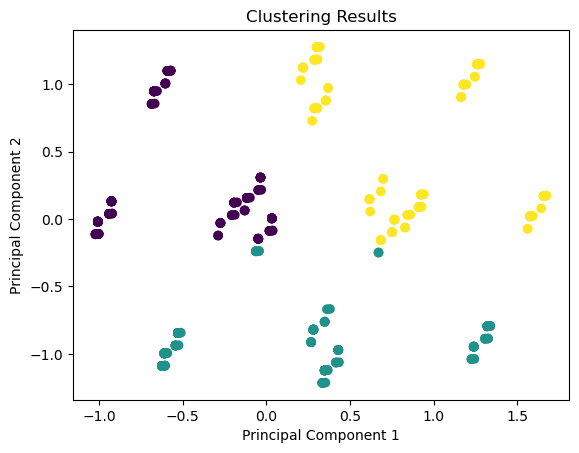

In [882]:
# Apply dimensionality reduction using PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(X)

# Perform clustering using K-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data_pca)

# Visualize the clusters
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clustering Results')
plt.show()

In [883]:
import scipy.cluster.hierarchy as sch

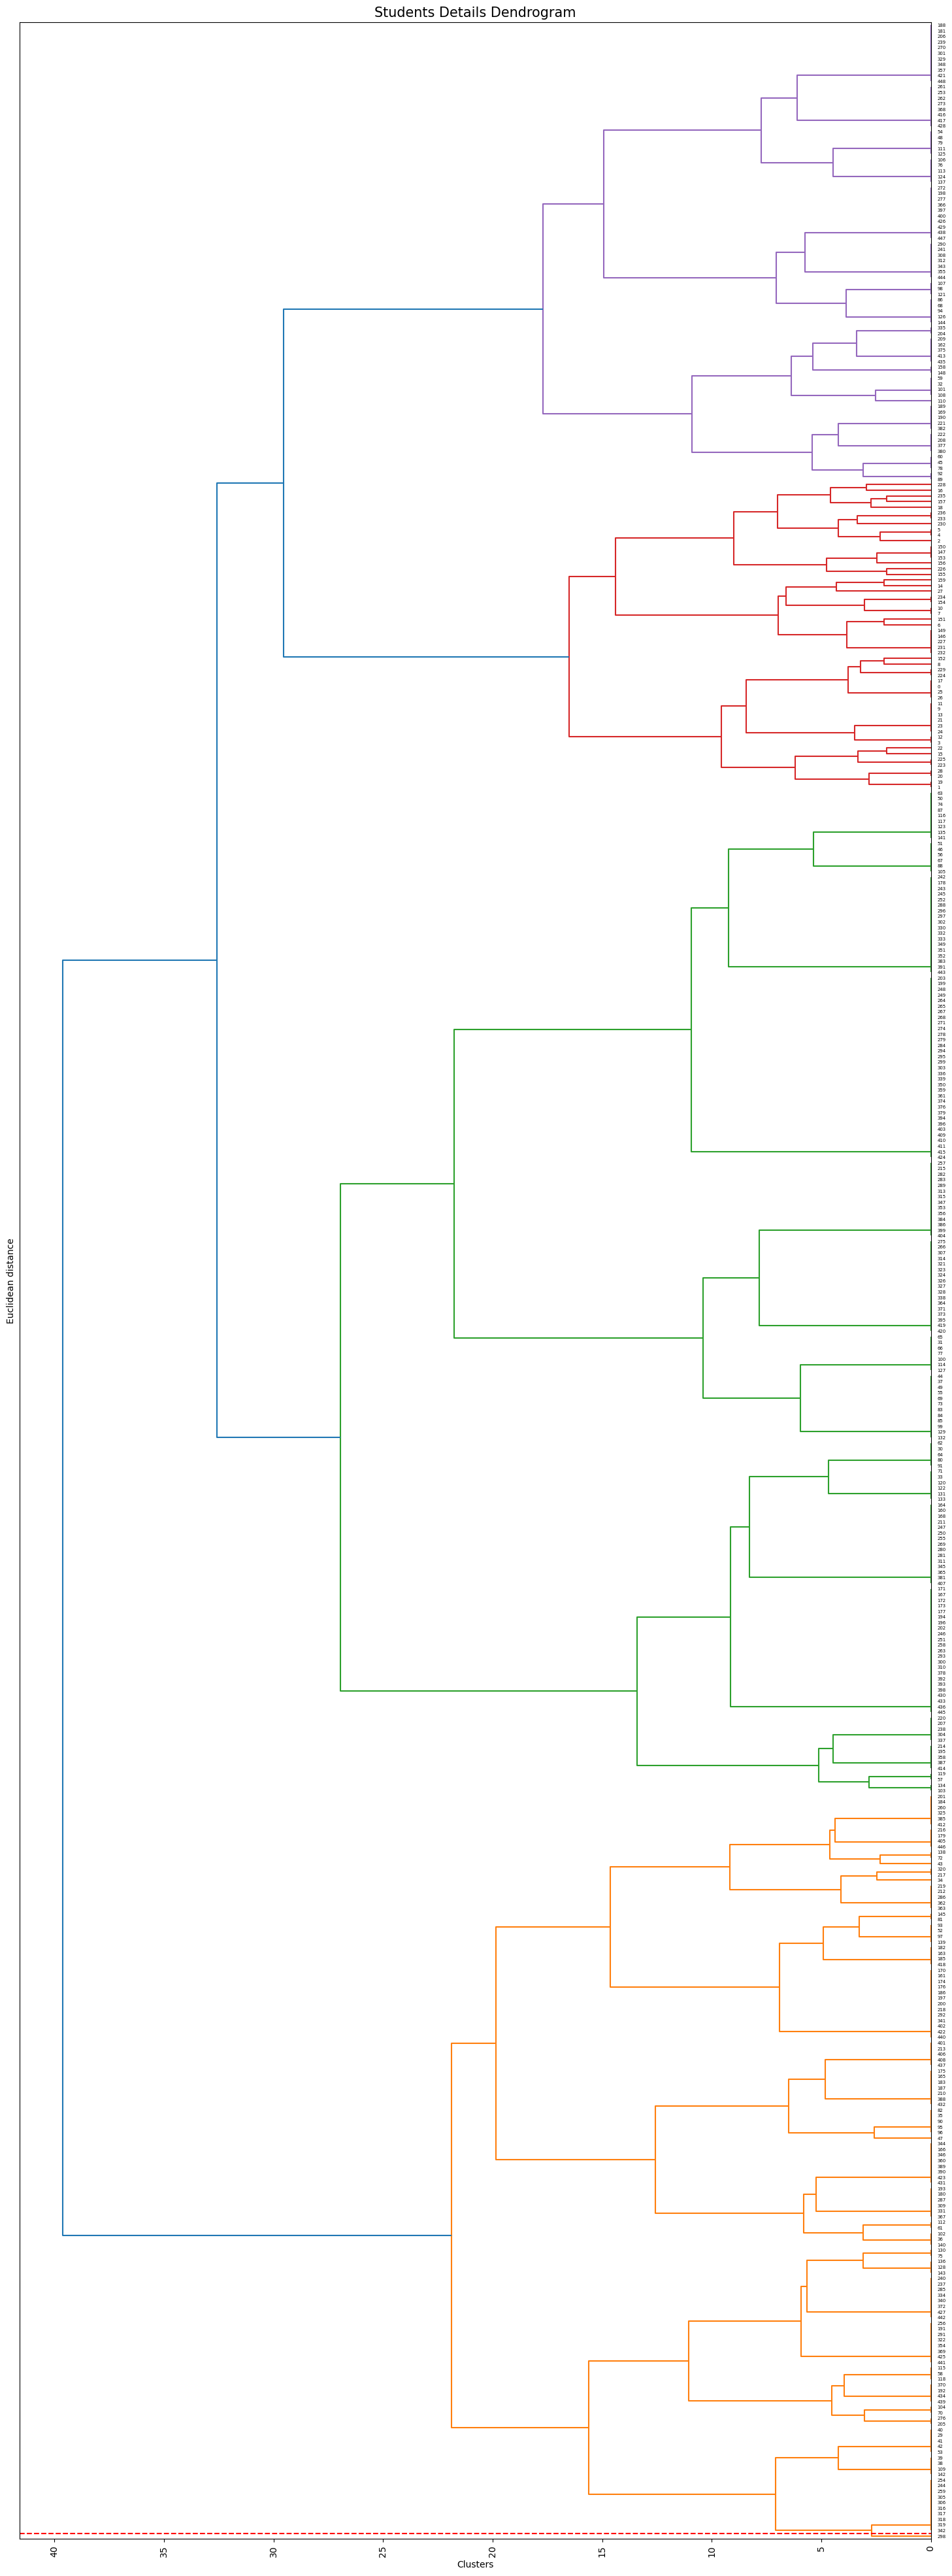

In [884]:
#plotting dendogram
plt.figure(figsize=(18, 50))
dendrogrm = sch.dendrogram(sch.linkage(X_scaled, method = 'ward'), orientation = 'left')
plt.axhline(y=9.0, color='r', linestyle='--')
ax = plt.gca()
ax.tick_params(axis='x', which='major', labelsize=10)
plt.title('Students Details Dendrogram',fontsize=15)
plt.xlabel('Clusters',fontsize=10)
plt.xticks(rotation=90)
plt.ylabel('Euclidean distance', fontsize=10)
plt.show()

# DBscan

In [885]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=6)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

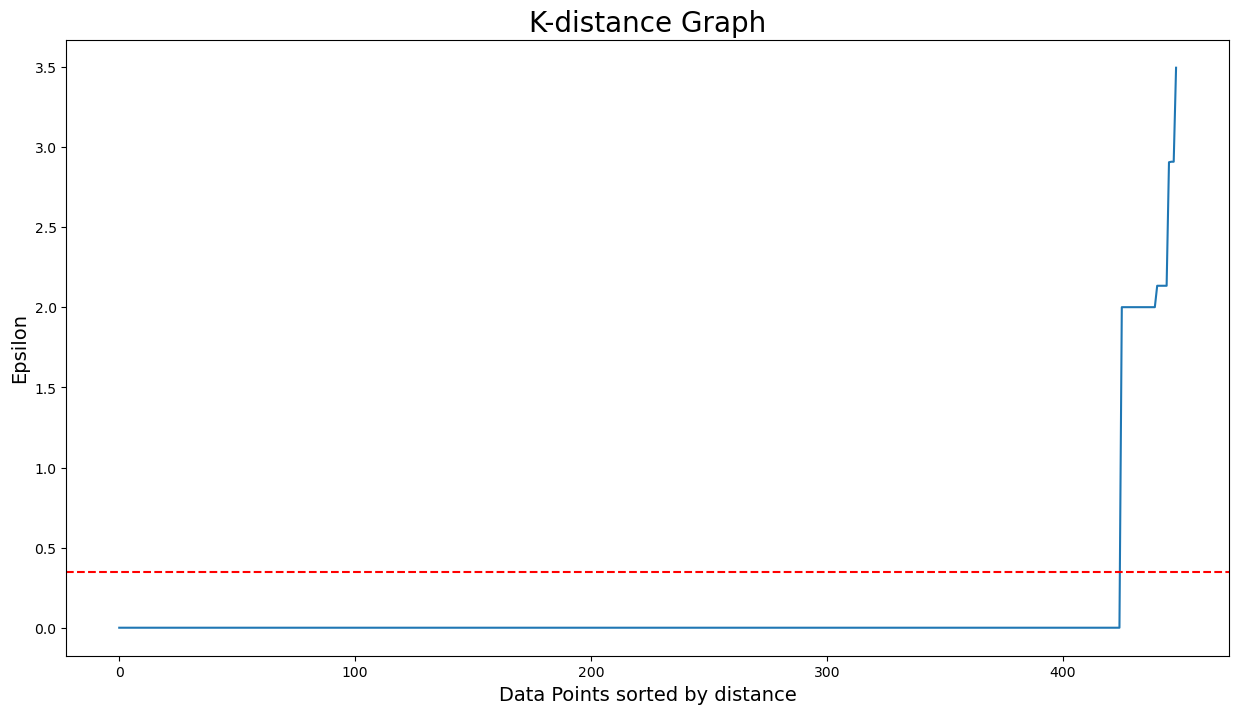

In [886]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(15,8))
plt.plot(distances)
plt.axhline(y=0.35, color='r', linestyle='--')
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

In [887]:
# # using hyper parameter calculating no of min_samples
# eps=0.45
# for min_samples in range(0,25):
#     model=DBSCAN(eps=eps,min_samples=min_samples)
#     cluster_labels = model.fit_predict(X_scaled)
#     x= cluster_labels +2
#     y = np.bincount(x)
#     ii = np.nonzero(y)[0]
#     results = list(zip(ii,y[ii]) )
#     print('eps=',eps,'| min_samples= ', min_samples, '| obtained clustering: ', results)
#     print()

In [888]:
model=DBSCAN(eps=0.45,min_samples=8)
model.fit(X_scaled)

DBSCAN(eps=0.45, min_samples=8)

In [889]:
legend_labels

['Cluster 0', 'Cluster 1', 'Cluster 2']

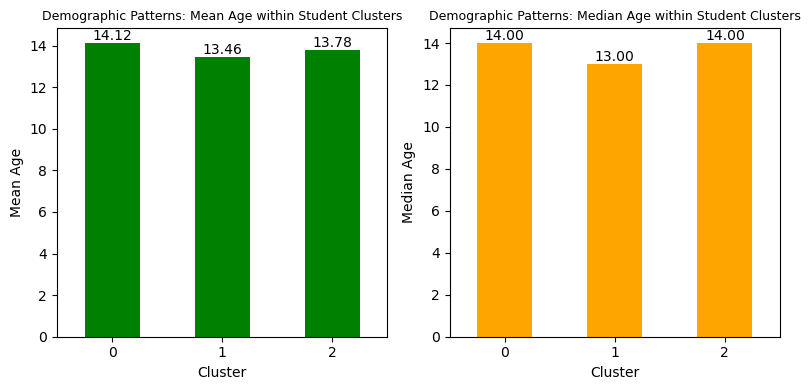

In [890]:
# Visualize demographic patterns within student clusters with values on bars
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Mean Age
ax1 = axes[0]
mean_age_plot = cluster_stats['Age']['mean'].plot(kind='bar', color='green', ax=ax1)
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Mean Age')
ax1.set_title('Demographic Patterns: Mean Age within Student Clusters', fontsize= 9)
ax1.set_xticklabels(mean_age_plot.get_xticklabels(), rotation=0)

# Add values on top of each bar
for p in mean_age_plot.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Median Age
ax2 = axes[1]
median_age_plot = cluster_stats['Age']['median'].plot(kind='bar', color='orange', ax=ax2)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Median Age')
ax2.set_title('Demographic Patterns: Median Age within Student Clusters', fontsize= 9)
ax2.set_xticklabels(median_age_plot.get_xticklabels(), rotation=0)

# Add values on top of each bar
for p in median_age_plot.patches:
    ax2.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


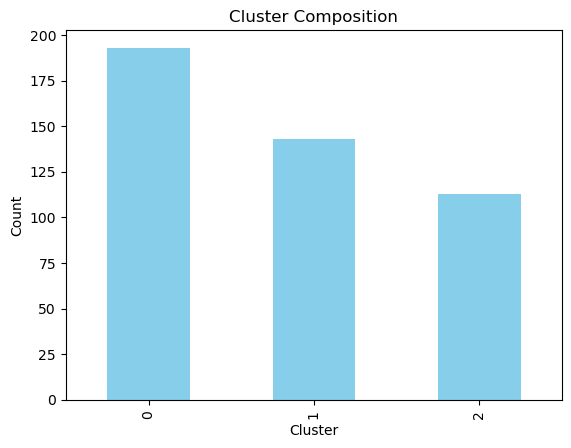

In [891]:
# Get the cluster labels for each student
cluster_labels = kmeans.labels_

# Analyze the cluster composition
cluster_counts = pd.Series(cluster_labels).value_counts()
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Composition')
plt.show()


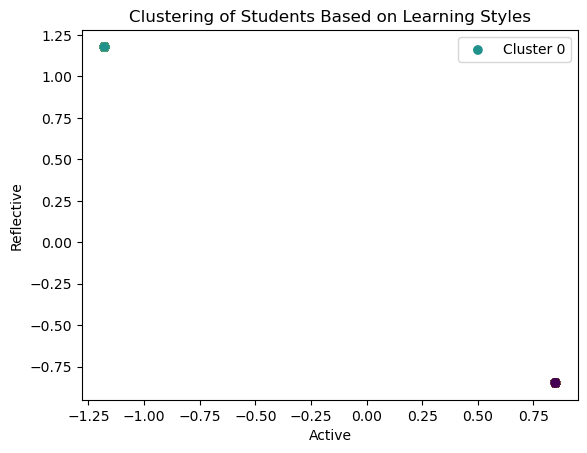

In [892]:
# Scatter plot of the clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.xlabel('Active')
plt.ylabel('Reflective')
plt.title('Clustering of Students Based on Learning Styles')

# Add legend
unique_clusters = np.unique(labels)
legend_labels = [f'Cluster {cluster}' for cluster in unique_clusters]
plt.legend(legend_labels)

plt.show()

In [893]:
models = {
    'K-means': KMeans(n_clusters=k, random_state=42),
    'DBSCAN': DBSCAN(eps=0.3, min_samples=5),
    'Agg. Hierarchical': AgglomerativeClustering(n_clusters=k),
    'GMM': GaussianMixture(n_components=k, random_state=42)
}

for model_name, model in models.items():
    if model_name != 'GMM':
        model.fit(X_scaled)
        labels = model.labels_
    else:
        model.fit(X_scaled)
        labels = model.predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    print(f"{model_name} - Silhouette Score: {silhouette_avg}")


K-means - Silhouette Score: 0.40601815078205145
DBSCAN - Silhouette Score: 0.6242233155961201
Agg. Hierarchical - Silhouette Score: 0.3871391017760388
GMM - Silhouette Score: 0.37076939481097976


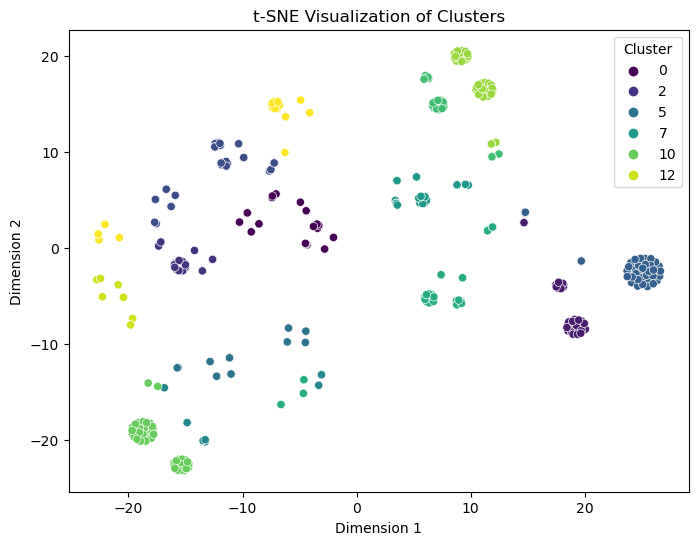

In [894]:
# Step 6: Advanced Visualization
# Dimensionality Reduction using t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame with the reduced dimensions and assigned cluster labels
df_tsne = pd.DataFrame(X_tsne, columns=['Dimension 1', 'Dimension 2'])
df_tsne['Cluster'] = labels

# Scatter plot with cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='Cluster', data=df_tsne, palette='viridis')
plt.title('t-SNE Visualization of Clusters')
plt.show()

Silhouette Score - K-means:  0.2586685983611975
Silhouette Score - DBSCAN:  0.6144694751365123
Silhouette Score - Hierarchical:  0.26886149647576785
Silhouette Score - GMM:  0.25209352329803925


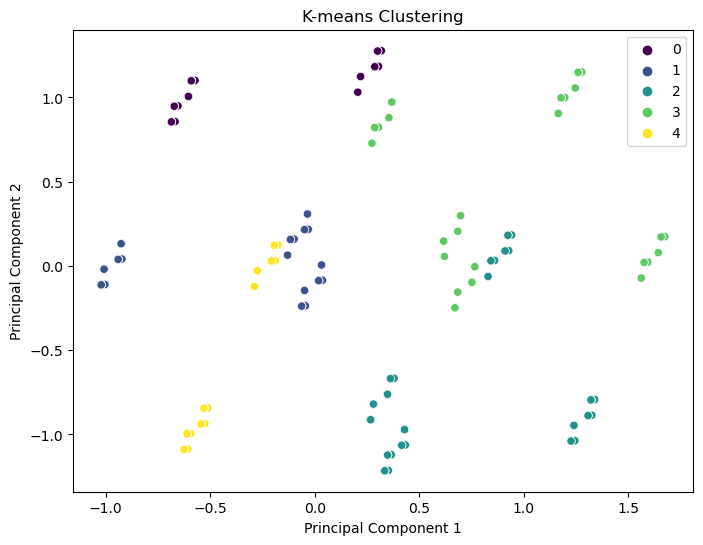

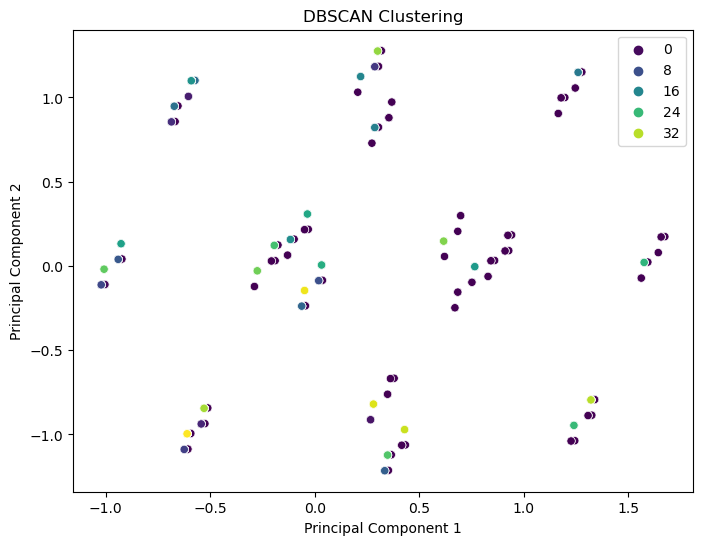

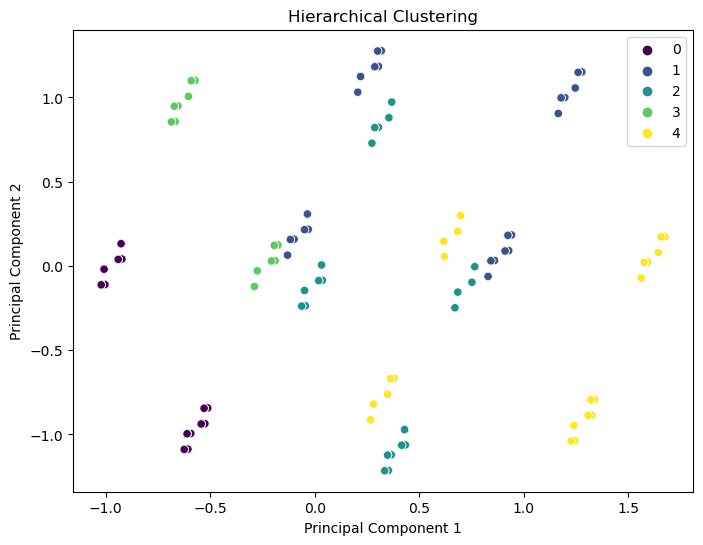

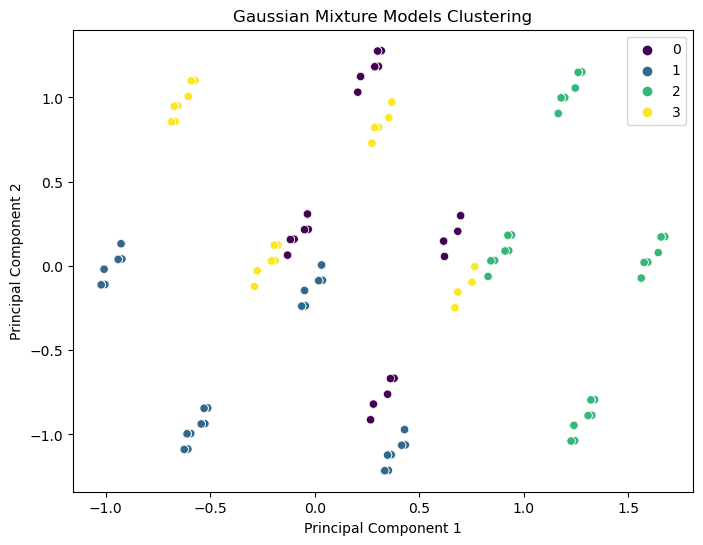

In [895]:
from sklearn.decomposition import PCA
# Step 4: Clustering Algorithm Selection
# K-means Clustering
data_scaled = X
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(data_scaled)

# Agglomerative Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=5)
hierarchical_labels = hierarchical.fit_predict(data_scaled)

# Gaussian Mixture Models (GMM)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(data_scaled)

# Step 5: Model Training and Evaluation
# Evaluate clustering models using silhouette score
print("Silhouette Score - K-means: ", silhouette_score(data_scaled, kmeans_labels))
print("Silhouette Score - DBSCAN: ", silhouette_score(data_scaled, dbscan_labels))
print("Silhouette Score - Hierarchical: ", silhouette_score(data_scaled, hierarchical_labels))
print("Silhouette Score - GMM: ", silhouette_score(data_scaled, gmm_labels))

# Step 6: Visualize Clusters
# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Visualize K-means Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=kmeans_labels, palette='viridis')
plt.title('K-means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Visualize DBSCAN Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=dbscan_labels, palette='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Visualize Agglomerative Hierarchical Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=hierarchical_labels, palette='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Visualize Gaussian Mixture Models Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=gmm_labels, palette='viridis')
plt.title('Gaussian Mixture Models Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()